In [53]:
import open3d as o3d
import cv2
import numpy as np
from ultralytics import YOLO
from scipy.spatial.transform import Rotation as R
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

image_path = "output_image.png"
ply_path = "output_pointcloud.ply"


model_path = "yolo12n.pt"
model = YOLO(model_path)

def read_image_and_pointcloud(image_path: str, ply_path: str):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pcd = o3d.io.read_point_cloud(ply_path)
    points = np.asarray(pcd.points)
    return image, points

img, cloud = read_image_and_pointcloud(image_path, ply_path)

# Camera intrinsic matrix K
K = np.array([
    [336.0996183406607, 0.0, 480.0],
    [0.0, 336.0996183406607, 300.0],
    [0.0, 0.0, 1.0]
])

# Extrinsics: from LiDAR to camera (rotation + translation)
quat = [0.7071, 0.0, 0.0, 0.7071]  # quaternion (x, y, z, w)
R_lidar_to_cam = R.from_quat(quat).as_matrix()
t_lidar_to_cam = np.array([-0.297, -0.296, -0.425]).reshape((3, 1))


def project_lidar_to_image(lidar_points, K, R, t):
    # Transform points from LiDAR frame to camera frame
    points_cam = (R @ lidar_points.T + t).T
    # Filter out points behind the camera
    in_front = points_cam[:, 2] > 0
    points_cam = points_cam[in_front]
    # Project to image plane
    proj = (K @ points_cam.T).T
    pixels = proj[:, :2] / proj[:, 2:3]
    return pixels, points_cam

def draw_projected_points_on_image(image, pixels, bboxes=None, color=(255, 165, 0)):
    img_copy = image.copy()
    
    # Draw projected points
    for pt in pixels.astype(int):
        x, y = pt
        if 0 <= x < img_copy.shape[1] and 0 <= y < img_copy.shape[0]:
            cv2.circle(img_copy, (x, y), 1, color, -1)
    
    # Draw and label bounding boxes
    if bboxes:
        for i, (x1, y1, x2, y2) in enumerate(bboxes):
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f"DETECTION #{i}"
            cv2.putText(img_copy, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (0, 255, 0), 2, lineType=cv2.LINE_AA)
    
    return img_copy


def extract_points_in_bbox(pixels, cam_points, bbox):
    x1, y1, x2, y2 = bbox
    in_bbox = (
        (pixels[:, 0] >= x1) & (pixels[:, 0] <= x2) &
        (pixels[:, 1] >= y1) & (pixels[:, 1] <= y2)
    )
    return cam_points[in_bbox]

def plot_depth_histogram(points_3d, bbox_index, num_bins=170):
    depths = points_3d[:, 2]
    hist, bin_edges = np.histogram(depths, bins=num_bins)

    plt.figure(figsize=(8, 4))
    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align='edge', color='orange', edgecolor='black')
    plt.title(f"Depth Histogram for Detection #{bbox_index}")
    plt.xlabel("Depth (Z in camera frame)")
    plt.ylabel("Number of Points")
    plt.grid(True)
    plt.show()

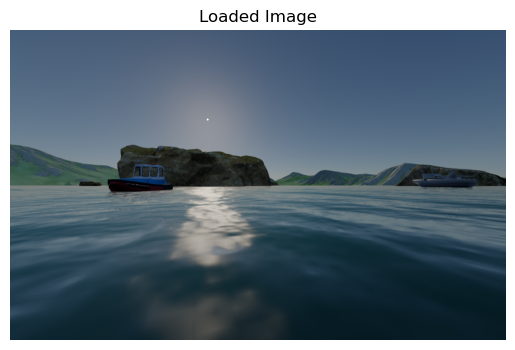

Loaded point cloud shape: (1504, 3)


In [54]:


# Show the image
plt.imshow(img)
plt.title("Loaded Image")
plt.axis("off")
plt.show()

print("Loaded point cloud shape:", cloud.shape)


0: 416x640 2 boats, 18.3ms
Speed: 1.8ms preprocess, 18.3ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)


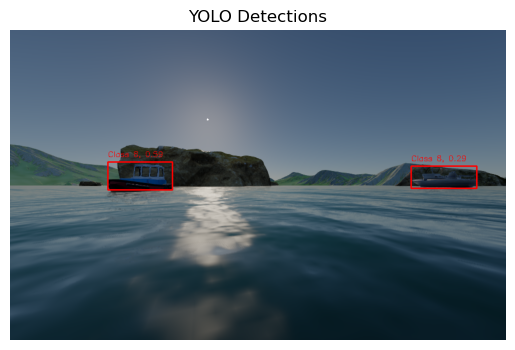

In [55]:
# Run detection
results = model(img)[0]  # We take the first image result

# Extract bounding boxes
detections = []
for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    conf = float(box.conf[0])
    cls = int(box.cls[0])
    detections.append({
        "bbox": (x1, y1, x2, y2),
        "confidence": conf,
        "class": cls
    })

# Draw detections for verification
image_copy = img.copy()
for det in detections:
    x1, y1, x2, y2 = det["bbox"]
    cv2.rectangle(image_copy, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(image_copy, f"Class {det['class']}, {det['confidence']:.2f}",
                (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

plt.imshow(image_copy)
plt.title("YOLO Detections")
plt.axis("off")
plt.show()

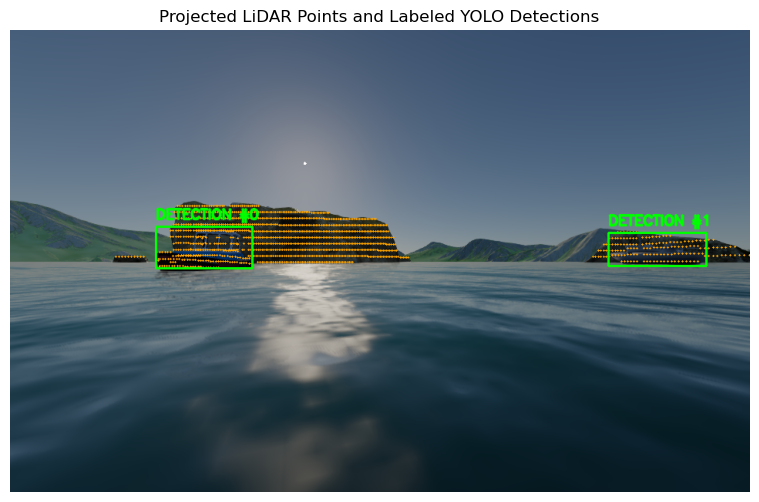

In [56]:
# Use projected LiDAR on image
pixels, cam_points = project_lidar_to_image(cloud, K, R_lidar_to_cam, t_lidar_to_cam)

# Extract bounding boxes
bboxes = [d["bbox"] for d in detections] if "detections" in locals() else [(250, 200, 390, 320)]

# Draw image with projected LiDAR points and labeled bounding boxes
overlay = draw_projected_points_on_image(img, pixels, bboxes)

# Show result
plt.figure(figsize=(10, 6))
plt.imshow(overlay)
plt.title("Projected LiDAR Points and Labeled YOLO Detections")
plt.axis("off")
plt.show()

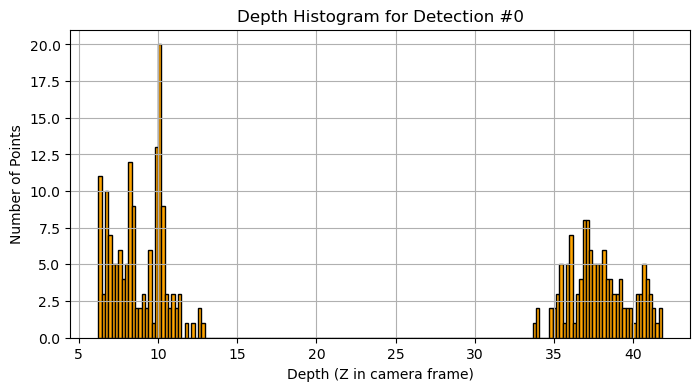

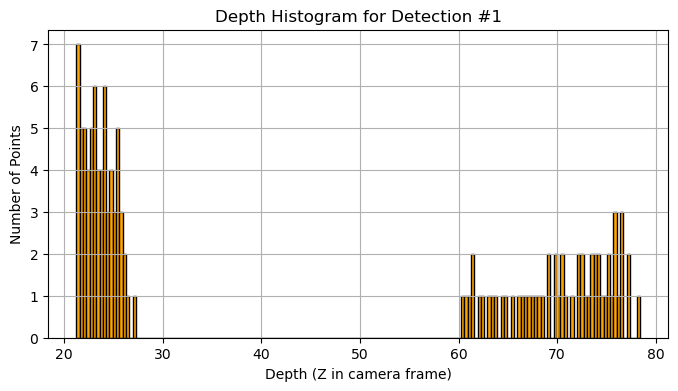

In [57]:


# --- Loop through all detections ---
if bboxes:
    for idx, bbox in enumerate(bboxes):
        points_in_frustum = extract_points_in_bbox(pixels, cam_points, bbox)
        if len(points_in_frustum) > 0:
            plot_depth_histogram(points_in_frustum, idx)
        else:
            print(f"No LiDAR points found in frustum of detection #{idx}")
else:
    print("No bounding boxes found.")

In [50]:
def estimate_k_by_gaps(hist, gap_threshold=5, min_gap_width=5):
    """
    Estimate the number of clusters based on well-separated gaps in the histogram.

    A gap is a sequence of at least `min_gap_width` consecutive bins with fewer than `gap_threshold` points.
    Each such gap indicates a separation between clusters.

    Returns:
        k_estimated: number of clusters = number of gaps + 1
    """
    gap_counter = 0
    consecutive_low = 0

    for count in hist:
        if count < gap_threshold:
            consecutive_low += 1
        else:
            if consecutive_low >= min_gap_width:
                gap_counter += 1
            consecutive_low = 0

    # Check if a gap ended at the last bin
    if consecutive_low >= min_gap_width:
        gap_counter += 1

    return gap_counter + 1

# Step 1: get histogram
depths = points_in_frustum[:, 2]
hist, bin_edges = np.histogram(depths, bins=60)

# Step 2: estimate k based on gaps
k_gap = estimate_k_by_gaps(hist, gap_threshold=5, min_gap_width=2)
print(f"Estimated k (gap-based): {k_gap}")

Estimated k (gap-based): 3


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


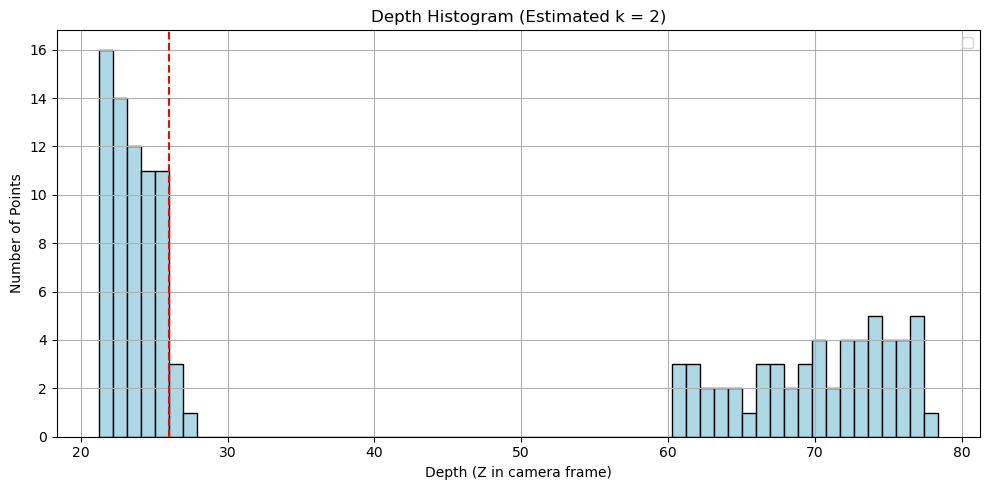

In [52]:
def plot_histogram_with_k(depths, hist, bin_edges, gap_threshold, min_gap_width, k):
    plt.figure(figsize=(10, 5))
    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align='edge',
            color=(173/255, 216/255, 230/255), edgecolor='black')

    # Title with estimated k
    plt.title(f"Depth Histogram (Estimated k = {k})")
    plt.xlabel("Depth (Z in camera frame)")
    plt.ylabel("Number of Points")
    plt.grid(True)

    # Optionally: visualize gaps
    consecutive_low = 0
    for i, count in enumerate(hist):
        if count < gap_threshold:
            consecutive_low += 1
        else:
            if consecutive_low >= min_gap_width:
                gap_start = bin_edges[i - consecutive_low]
                plt.axvline(gap_start, color='red', linestyle='--', label='Detected Gap' if i == 0 else "")
            consecutive_low = 0

    # Final gap at end
    if consecutive_low >= min_gap_width:
        gap_start = bin_edges[-consecutive_low]
        plt.axvline(gap_start, color='red', linestyle='--')

    plt.legend()
    plt.tight_layout()
    plt.show()

depths = points_in_frustum[:, 2]
hist, bin_edges = np.histogram(depths, bins=60)

k = estimate_k_by_gaps(hist, gap_threshold=5, min_gap_width=5)

plot_histogram_with_k(depths, hist, bin_edges, gap_threshold=5, min_gap_width=5, k=k)